In [1]:
import pandas as pd


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

1.Load the dataset 

In [3]:
df=pd.read_csv("c:\\Users\\a\\Downloads\\india_housing_prices.csv")

- The  original dataset contained approximately 2.5 lakh rows. Due to memory limitaions on the availabble hard momory So I used 50,000 rows for model training and evaluation preserving a representative subdet of data.

In [4]:
df=df.iloc[:50000]

In [5]:
df.shape

(50000, 23)

In [6]:
df.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object

2.Null value analysis:

In [7]:
(df.isnull().sum() / df.shape[0]) * 100

ID                                0.0
State                             0.0
City                              0.0
Locality                          0.0
Property_Type                     0.0
BHK                               0.0
Size_in_SqFt                      0.0
Price_in_Lakhs                    0.0
Price_per_SqFt                    0.0
Year_Built                        0.0
Furnished_Status                  0.0
Floor_No                          0.0
Total_Floors                      0.0
Age_of_Property                   0.0
Nearby_Schools                    0.0
Nearby_Hospitals                  0.0
Public_Transport_Accessibility    0.0
Parking_Space                     0.0
Security                          0.0
Amenities                         0.0
Facing                            0.0
Owner_Type                        0.0
Availability_Status               0.0
dtype: float64

3.Duplicate detection and removal: 

In [8]:
df.duplicated().sum()

np.int64(0)

4. Data type correction:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              50000 non-null  int64  
 1   State                           50000 non-null  object 
 2   City                            50000 non-null  object 
 3   Locality                        50000 non-null  object 
 4   Property_Type                   50000 non-null  object 
 5   BHK                             50000 non-null  int64  
 6   Size_in_SqFt                    50000 non-null  int64  
 7   Price_in_Lakhs                  50000 non-null  float64
 8   Price_per_SqFt                  50000 non-null  float64
 9   Year_Built                      50000 non-null  int64  
 10  Furnished_Status                50000 non-null  object 
 11  Floor_No                        50000 non-null  int64  
 12  Total_Floors                    

- NO data correction was required

In [10]:
df['State'] = df['State'].astype('category')

memory check

In [11]:
# Step 1: Memory usage before conversion
before_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage before conversion: {before_mem / 1024**2:.2f} MB")

# Step 2: Convert object columns to category
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].apply(lambda x: x.astype('category'))

# Step 3: Memory usage after conversion
after_mem = df.memory_usage(deep=True).sum()
print(f"Memory usage after conversion: {after_mem / 1024**2:.2f} MB")



Memory usage before conversion: 38.89 MB
Memory usage after conversion: 4.96 MB


5. **Descriptive statistics and skewness:**

Numeric columns

In [12]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2.999460,2754.493920,254.356808,0.130579,2006.504320,15.008960,15.412320,18.495680,5.496400,5.497640
std,14433.901067,1.420232,1302.847463,140.979945,0.130887,9.780291,8.956946,8.667697,9.780291,2.881568,2.876115
min,1.000000,1.000000,500.000000,10.020000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,12500.750000,2.000000,1622.000000,132.587500,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,25000.500000,3.000000,2756.000000,253.990000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,6.000000
75%,37500.250000,4.000000,3876.000000,375.345000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,50000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [13]:
# i check skew data for numeric columns
df.skew(numeric_only=True)

ID                  0.000000
BHK                -0.000891
Size_in_SqFt       -0.006476
Price_in_Lakhs      0.007311
Price_per_SqFt      2.304116
Year_Built          0.001064
Floor_No            0.000480
Total_Floors        0.012278
Age_of_Property    -0.001064
Nearby_Schools      0.000385
Nearby_Hospitals   -0.001157
dtype: float64

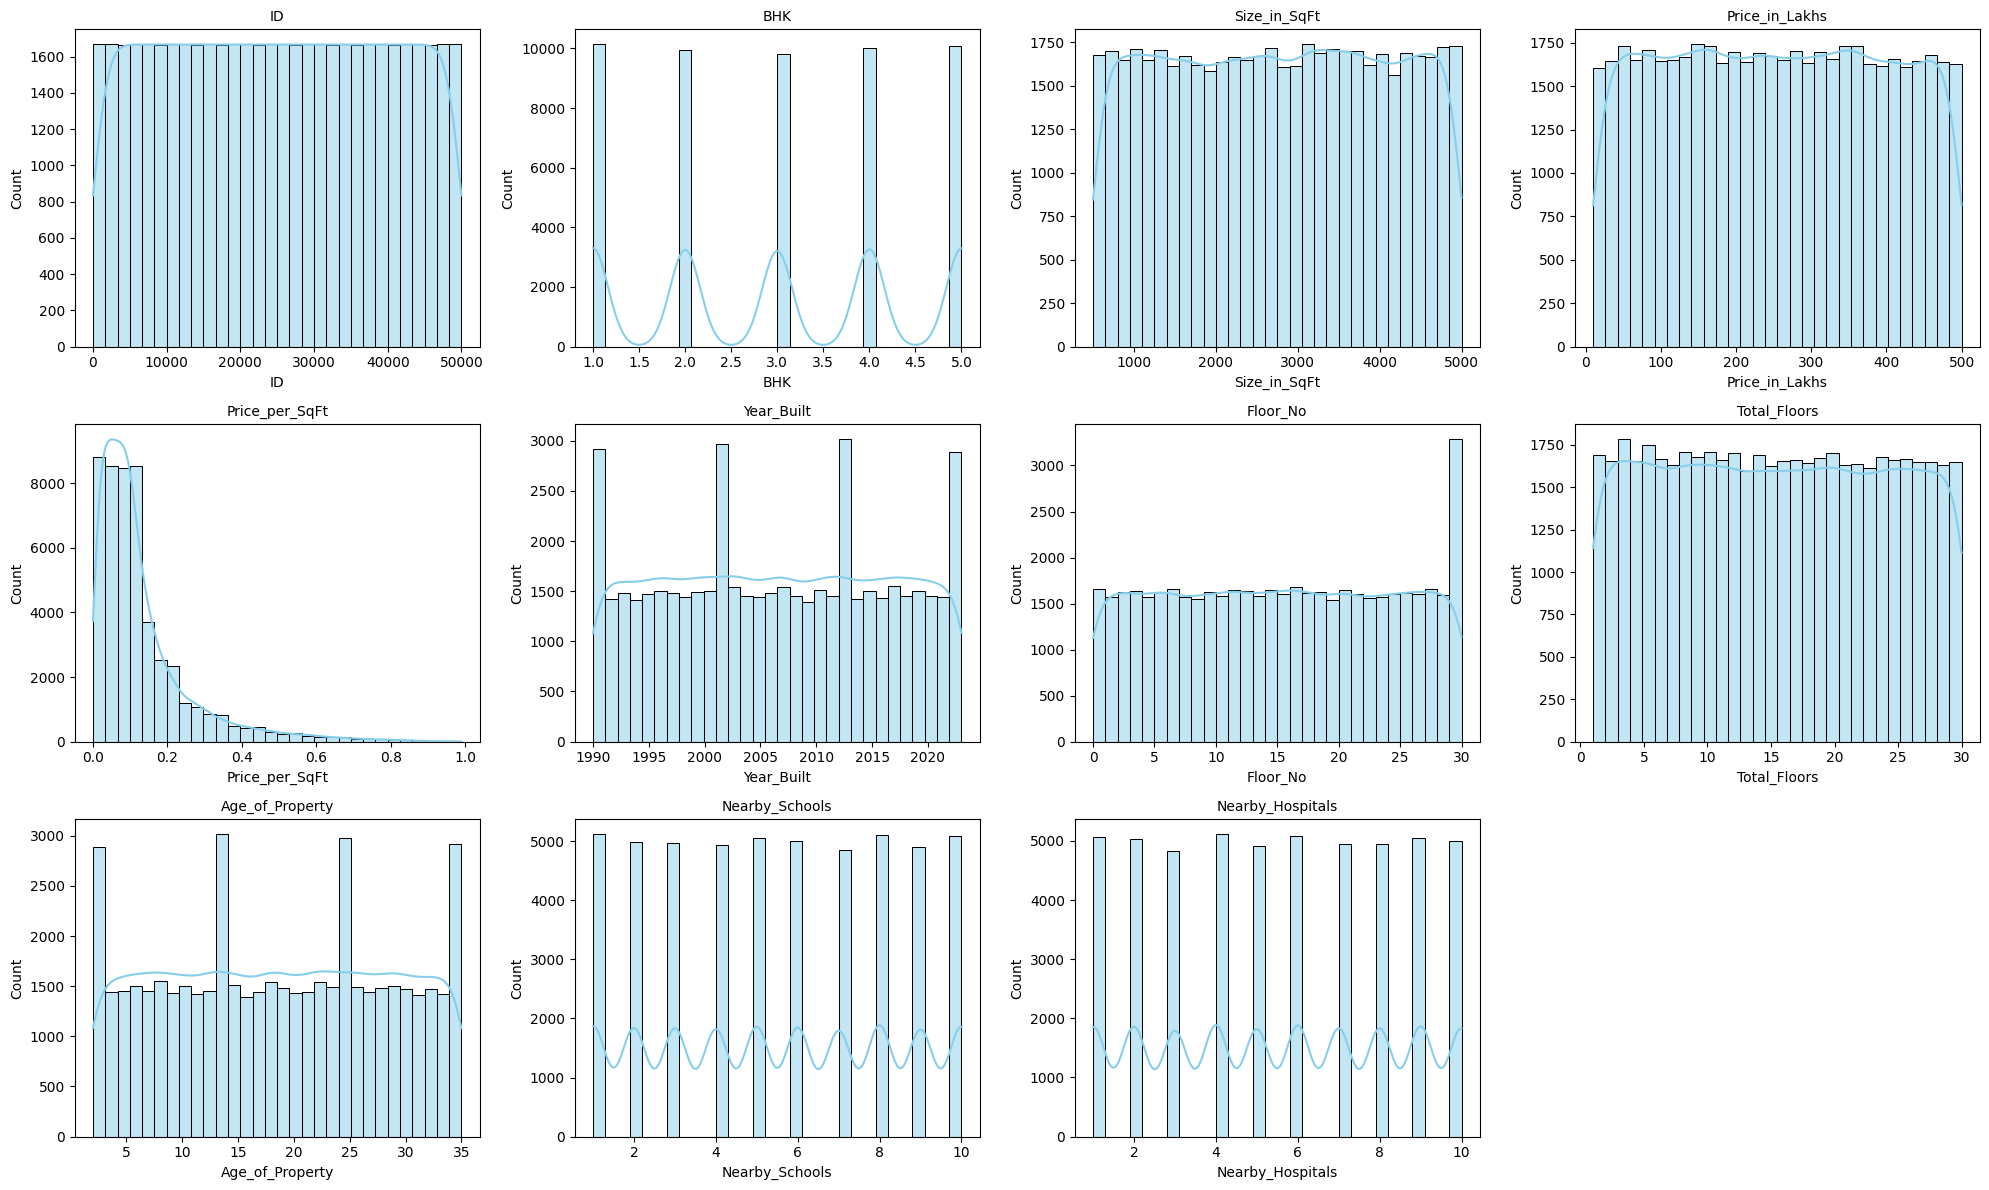

<Figure size 640x480 with 0 Axes>

In [14]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Plot each numeric column
n_cols = 4   # number of plots per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="skyblue")
    axes[i].set_title(f'{col}', fontsize=10)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
plt.savefig("numeric_columns_distribution.png",)  # saves as PNG
plt.show()

Categorical colimns

In [15]:
df.describe(include=["object","category"])

,State,City,Locality,Property_Type,Furnished_Status,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,20,42,500,3,3,3,2,2,325,4,3,2
top,Andhra Pradesh,Vijayawada,Locality_388,Independent House,Furnished,Low,Yes,No,Gym,East,Builder,Ready_to_Move
freq,2594,1333,131,16696,16690,16784,25001,25051,2037,12556,16747,25120


6. Outlier detection with IQR:

In [16]:
import pandas as pd

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_report = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    
    outlier_report[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    }

# Convert to DataFrame for readability
report_df = pd.DataFrame(outlier_report).T
print(report_df)


                          Q1         Q3         IQR  Lower Bound  Upper Bound  \
ID                12500.7500  37500.250  24999.5000 -24998.50000  74999.50000   
BHK                   2.0000      4.000      2.0000     -1.00000      7.00000   
Size_in_SqFt       1622.0000   3876.000   2254.0000  -1759.00000   7257.00000   
Price_in_Lakhs      132.5875    375.345    242.7575   -231.54875    739.48125   
Price_per_SqFt        0.0500      0.160      0.1100     -0.11500      0.32500   
Year_Built         1998.0000   2015.000     17.0000   1972.50000   2040.50000   
Floor_No              7.0000     23.000     16.0000    -17.00000     47.00000   
Total_Floors          8.0000     23.000     15.0000    -14.50000     45.50000   
Age_of_Property      10.0000     27.000     17.0000    -15.50000     52.50000   
Nearby_Schools        3.0000      8.000      5.0000     -4.50000     15.50000   
Nearby_Hospitals      3.0000      8.000      5.0000     -4.50000     15.50000   

                  Outlier C

7. Visualizations (all five types required):

- A line plot 

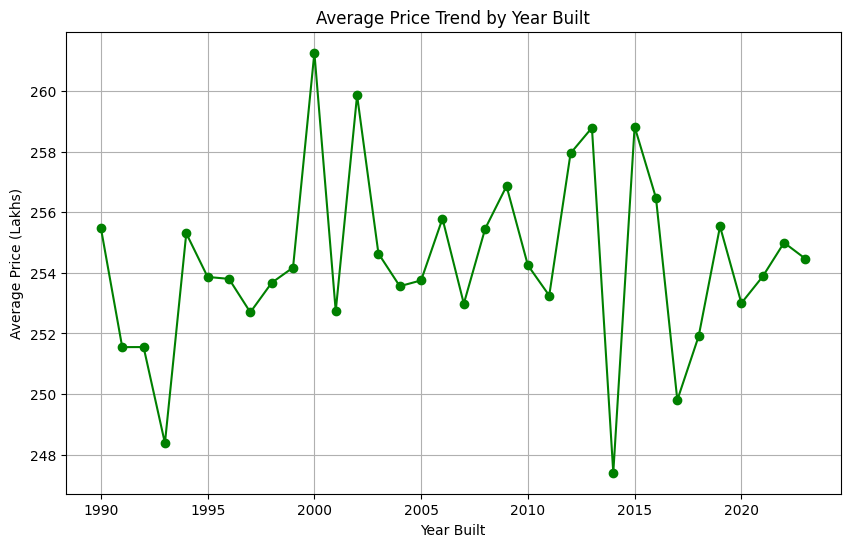

In [52]:
# Step 1: Group by year and compute average price
yearly_avg = df.groupby('Year_Built')['Price_in_Lakhs'].mean().sort_index()

# Step 2: Plot the average price trend
plt.figure(figsize=(10,6))
plt.plot(yearly_avg.index, yearly_avg.values, color='green', marker='o')

# Step 3: Add labels and title
plt.title("Average Price Trend by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average Price (Lakhs)")
plt.grid(True)
plt.show()


- A bar chart 

C:\Users\a\AppData\Local\Temp\ipykernel_8672\1639832871.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df.groupby('State')['Price_in_Lakhs'].mean()


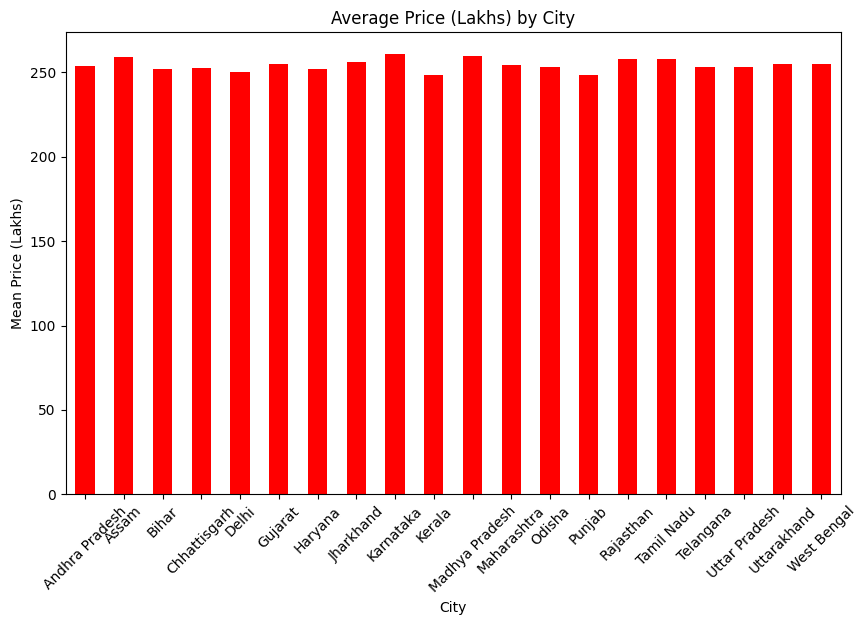

In [53]:
# Example: numeric column = 'Price_in_Lakhs', categorical column = 'City'
mean_values = df.groupby('State')['Price_in_Lakhs'].mean()

# Plot using df.plot.bar()
mean_values.plot.bar(color='red', figsize=(10,6))

# Add title and axis labels
plt.title("Average Price (Lakhs) by City")
plt.xlabel("City")
plt.ylabel("Mean Price (Lakhs)")
plt.xticks(rotation=45)  # rotate labels for readability
plt.show()

- A histogram 

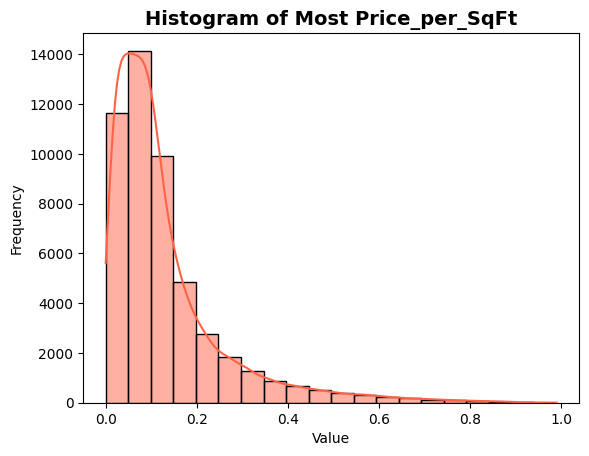

In [54]:
sns.histplot(df['Price_per_SqFt'], bins=20, kde=True, color="tomato")

plt.title("Histogram of Most Price_per_SqFt", fontsize=14, fontweight='bold')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

- A scatter plot

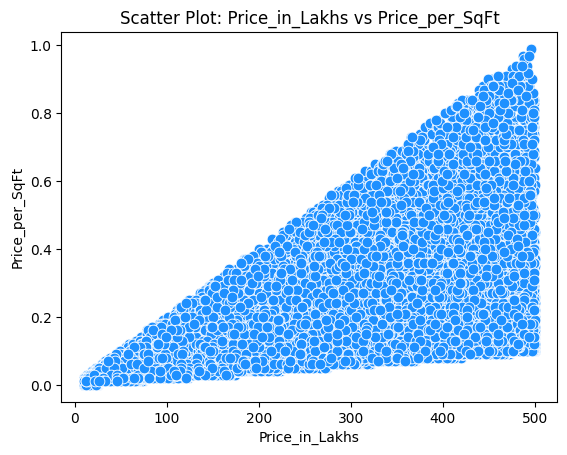

In [55]:
# Example: numeric columns = 'income' and 'spending'
sns.scatterplot(x=df['Price_in_Lakhs'], y=df['Price_per_SqFt'], color="dodgerblue", s=60)

plt.title("Scatter Plot: Price_in_Lakhs vs Price_per_SqFt")
plt.xlabel("Price_in_Lakhs")
plt.ylabel("Price_per_SqFt")
plt.show()

- A box plot

C:\Users\a\AppData\Local\Temp\ipykernel_8672\2057220585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Property_Type'], y=df['Price_in_Lakhs'], palette="Set2",)


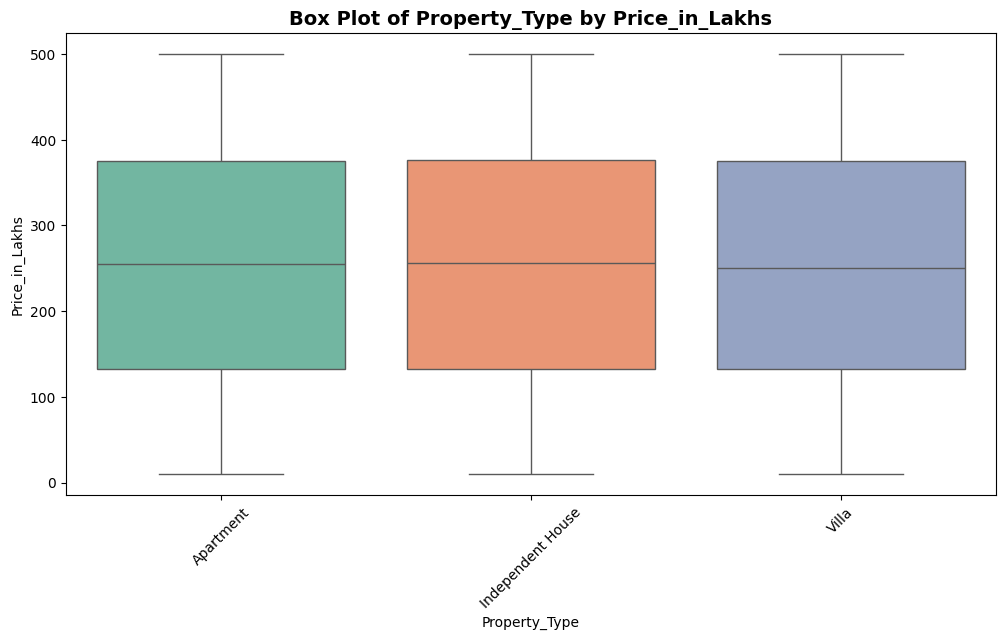

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
# Example: numeric column = 'sales', categorical column = 'region'
sns.boxplot(x=df['Property_Type'], y=df['Price_in_Lakhs'], palette="Set2",)

plt.title("Box Plot of Property_Type by Price_in_Lakhs", fontsize=14, fontweight='bold')
plt.xlabel("Property_Type")
plt.ylabel("Price_in_Lakhs")
plt.xticks(rotation=45)
plt.show()


8. Correlation heat map:

In [57]:
df.corr(numeric_only=True)

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
ID,1.000000,0.001187,0.005177,-0.001113,-0.005825,0.009639,0.000529,0.002502,-0.009639,-0.007897,-0.002713
BHK,0.001187,1.000000,-0.001695,-0.004213,0.000261,0.000142,0.003431,-0.003114,-0.000142,-0.001533,0.001442
Size_in_SqFt,0.005177,-0.001695,1.000000,-0.004799,-0.617406,0.009909,0.002757,-0.002567,-0.009909,0.003786,0.004162
Price_in_Lakhs,-0.001113,-0.004213,-0.004799,1.000000,0.554929,0.001928,-0.000132,-0.010485,-0.001928,-0.002696,-0.005799
Price_per_SqFt,-0.005825,0.000261,-0.617406,0.554929,1.000000,-0.005330,-0.005956,-0.003549,0.005330,-0.002071,-0.007708
Year_Built,0.009639,0.000142,0.009909,0.001928,-0.005330,1.000000,0.000670,0.006972,-1.000000,0.002999,-0.001387
Floor_No,0.000529,0.003431,0.002757,-0.000132,-0.005956,0.000670,1.000000,0.004715,-0.000670,0.003337,-0.004921
Total_Floors,0.002502,-0.003114,-0.002567,-0.010485,-0.003549,0.006972,0.004715,1.000000,-0.006972,-0.002209,-0.009574
Age_of_Property,-0.009639,-0.000142,-0.009909,-0.001928,0.005330,-1.000000,-0.000670,-0.006972,1.000000,-0.002999,0.001387
Nearby_Schools,-0.007897,-0.001533,0.003786,-0.002696,-0.002071,0.002999,0.003337,-0.002209,-0.002999,1.000000,-0.006104


<Axes: >

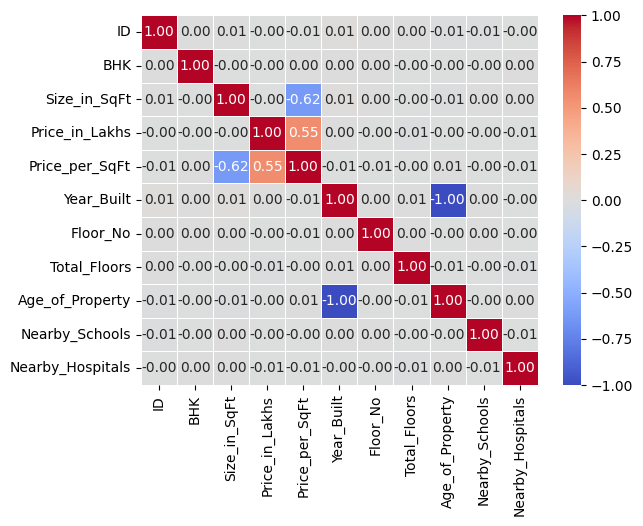

In [58]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

I used a correlation heatmap to identify relationship 
between numerical fetures.
I found that price_in_lakhs and Price_per_SqFT has a moderate positve
correlation(0.56),while Size_in_SqFt and Price_per_SqFt showed a moderate
negative correlation(-0.61). Year_built and Age_of_property had a perfect negative correlation (-1.0) which is expected because older ,properties have earlier contrucation years.


9. a. Imputation strategy comparison.

In [59]:
# Step 1: Identify skewness for numeric columns
from scipy.stats import skew
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
skew_values = df[numeric_cols].apply(lambda x: skew(x.dropna()))

# Step 2: Pick top 2 columns with highest absolute skewness
top2_cols = skew_values.abs().sort_values(ascending=False).head(2).index
print("Top 2 skewed columns:", top2_cols.tolist())

# Step 3: Compute mean and median for each column (before imputation)
for col in top2_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, skew={skew_values[col]:.2f}")

# Step 4: Choose imputation strategy based on skewness direction
# Positively skewed → median; Negatively skewed → median (since mean is pulled away)
for col in top2_cols:
    chosen_val = df[col].median()
    df[col] = df[col].fillna(chosen_val)

Top 2 skewed columns: ['Price_per_SqFt', 'Total_Floors']
Price_per_SqFt: mean=0.13, median=0.09, skew=2.30
Total_Floors: mean=15.41, median=15.00, skew=0.01


9.b. Spearman rank correlation.

In [60]:
# Step 1: Pearson correlation (linear relationships)
pearson_corr = df.corr(method='pearson',	numeric_only=True)

# Step 2: Spearman correlation (rank-based monotonic relationships)
spearman_corr = df.corr(method='spearman', numeric_only=True)

# Step 3: Absolute difference matrix
diff_matrix = (spearman_corr - pearson_corr).abs()

# Step 4: Extract top 3 pairs with largest differences
pairs = []
cols = df.select_dtypes(include=['int64','float64']).columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        pairs.append((cols[i], cols[j], diff_matrix.loc[cols[i], cols[j]]))

top3 = sorted(pairs, key=lambda x: x[2], reverse=True)[:3]

# Step 5: Print results
print("Pearson Correlation Matrix:\n", pearson_corr)
print("\nSpearman Correlation Matrix:\n", spearman_corr)

print("\nTop 3 pairs with largest |Spearman - Pearson| difference:")
for c1, c2, diff in top3:
    print(f"{c1} vs {c2}: |Spearman-Pearson|={diff:.3f}, "
          f"Pearson={pearson_corr.loc[c1,c2]:.3f}, Spearman={spearman_corr.loc[c1,c2]:.3f}")


Pearson Correlation Matrix:
                         ID       BHK  Size_in_SqFt  Price_in_Lakhs  \
ID                1.000000  0.001187      0.005177       -0.001113   
BHK               0.001187  1.000000     -0.001695       -0.004213   
Size_in_SqFt      0.005177 -0.001695      1.000000       -0.004799   
Price_in_Lakhs   -0.001113 -0.004213     -0.004799        1.000000   
Price_per_SqFt   -0.005825  0.000261     -0.617406        0.554929   
Year_Built        0.009639  0.000142      0.009909        0.001928   
Floor_No          0.000529  0.003431      0.002757       -0.000132   
Total_Floors      0.002502 -0.003114     -0.002567       -0.010485   
Age_of_Property  -0.009639 -0.000142     -0.009909       -0.001928   
Nearby_Schools   -0.007897 -0.001533      0.003786       -0.002696   
Nearby_Hospitals -0.002713  0.001442      0.004162       -0.005799   

                  Price_per_SqFt  Year_Built  Floor_No  Total_Floors  \
ID                     -0.005825    0.009639  0.000529    

9. c. Grouped aggregation. 

In [61]:
grouped_stats = df.groupby("Property_Type")["Price_in_Lakhs"].agg(['mean', 'std', 'count'])

print(grouped_stats)

                         mean         std  count
Property_Type                                   
Apartment          254.604895  140.774415  16652
Independent House  254.907307  141.413805  16696
Villa              253.556767  140.754370  16652


C:\Users\a\AppData\Local\Temp\ipykernel_8672\2534667929.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stats = df.groupby("Property_Type")["Price_in_Lakhs"].agg(['mean', 'std', 'count'])


10. Save the clean dataset 

In [62]:
df.drop(columns=['ID'], inplace=True)

df.drop(columns=['Price_per_SqFt','Year_Built',"Locality"], inplace=True)


In [63]:
df.to_csv("cleaned_Housing_data.csv", index=False)